# Trim & Filter messages
- Trim with RemoveMessage (deletes messages in the actual state)
- Trim just before sending to LLM (retains all messages in state)
- Trim with trim_messages (from langchain_core.messages import trim_messages) (if we want to trim messages based on token limit)

### Boilerplate code - llm initiation

In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv

load_dotenv("./env")

google_api_key = os.getenv("GOOGLE_API_KEY")
openai_api_key = os.getenv("OPENAI_API_KEY")

google_llm = ChatGoogleGenerativeAI(
    temperature=0, 
    model="gemini-2.5-flash", 
    api_key=google_api_key,
    max_tokens=200
)

openai_llm = ChatOpenAI(
    temperature=0, 
    model="gpt-4", 
    api_key=openai_api_key
)

# openai_llm.invoke("Hello")

### 1. Trim with RemoveMessage

================================== Ai Message ==================================

You heard it already.
================================ Human Message =================================

Be nice to me!
================================== Ai Message ==================================

Absolutely! That's my default setting. I'm here to be helpful, respectful, and friendly.

How can I assist you today? What's on your mind?


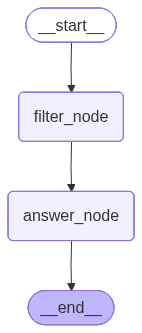

In [3]:
from langgraph.graph import StateGraph, START, END, MessagesState
from typing import TypedDict
from IPython.display import display, Image
from langchain_core.messages import RemoveMessage, AIMessage, HumanMessage


def filter_node(state: MessagesState):
    delete_messages = [RemoveMessage(id=msg.id) for msg in state['messages'][:-2]]
    return {"messages": delete_messages}

def answer_node(state: MessagesState):
    return {"messages": google_llm.invoke(state['messages'])}


messages = [
    HumanMessage(content='Hi, I am in Serengati', id='1'),
    AIMessage(content='So what. You do whatever you want. IDC.', id='2'),
    HumanMessage(content='What!', id='3'),
    AIMessage(content='You heard it already.', id='4'),
    HumanMessage(content='Be nice to me!', id='5')
]


builder = StateGraph(MessagesState)

builder.add_node("filter_node", filter_node)
builder.add_node("answer_node", answer_node)

builder.add_edge(START, "filter_node")
builder.add_edge("filter_node", "answer_node")
builder.add_edge("answer_node", END)

graph = builder.compile()

res = graph.invoke({"messages": messages})

for msg in res['messages']:
    msg.pretty_print()

display(Image(graph.get_graph().draw_mermaid_png()))

### 2. Trim just before sending it to LLM

Filtered messages: [AIMessage(content='You heard it already.', additional_kwargs={}, response_metadata={}, id='4'), HumanMessage(content='Be nice to me!', additional_kwargs={}, response_metadata={}, id='5')]
================================ Human Message =================================

Hi, I am in Serengati
================================== Ai Message ==================================

So what. You do whatever you want. IDC.
================================ Human Message =================================

What!
================================== Ai Message ==================================

You heard it already.
================================ Human Message =================================

Be nice to me!
================================== Ai Message ==================================

Absolutely! That's my main goal.

How can I help you today, in the kindest way possible? 😊


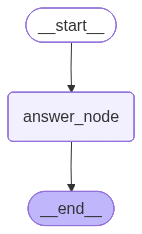

In [17]:
from langgraph.graph import StateGraph, START, END, MessagesState
from typing import TypedDict
from IPython.display import display, Image
from langchain_core.messages import AIMessage, HumanMessage

def answer_node(state: MessagesState):
    filtered_messages = state["messages"][-2:]
    print(f"Filtered messages: {filtered_messages}")
    return {"messages": google_llm.invoke(filtered_messages)}


messages = [
    HumanMessage(content='Hi, I am in Serengati', id='1'),
    AIMessage(content='So what. You do whatever you want. IDC.', id='2'),
    HumanMessage(content='What!', id='3'),
    AIMessage(content='You heard it already.', id='4'),
    HumanMessage(content='Be nice to me!', id='5')
]

builder = StateGraph(MessagesState)

builder.add_node("answer_node", answer_node)

builder.add_edge(START, "answer_node")
builder.add_edge("answer_node", END)

graph = builder.compile()

res = graph.invoke({"messages": messages})

for msg in res['messages']:
    msg.pretty_print()

display(Image(graph.get_graph().draw_mermaid_png()))

### 3. Trim with trim_messages (if we want to trim messages based on token limit)


Trimmed messages
================================ Human Message =================================

What!
================================== Ai Message ==================================

You heard it already.
================================ Human Message =================================

Be nice to me!
================================ END =================================
================================ Human Message =================================

Hi, I am in Serengati
================================== Ai Message ==================================

So what. You do whatever you want. IDC.
================================ Human Message =================================

What!
================================== Ai Message ==================================

You heard it already.
================================ Human Message =================================

Be nice to me!
================================== Ai Message ==================================

You're absolutely right! M

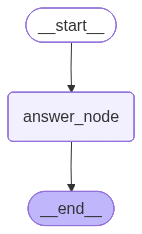

In [ ]:
from langgraph.graph import StateGraph, START, END, MessagesState
from typing import TypedDict
from IPython.display import display, Image
from langchain_core.messages import AIMessage, HumanMessage, trim_messages

def answer_node(state: MessagesState):
    trimmed_messages = trim_messages(
        state['messages'],
        max_tokens=20,
        strategy="last",
        allow_partial=True,
        token_counter=google_llm
    )
    
    for msg in trimmed_messages:
        msg.pretty_print()

    return {"messages": google_llm.invoke(trimmed_messages)}


messages = [
    HumanMessage(content='Hi, I am in Serengati', id='1'),
    AIMessage(content='So what. You do whatever you want. IDC.', id='2'),
    HumanMessage(content='What!', id='3'),
    AIMessage(content='You heard it already.', id='4'),
    HumanMessage(content='Be nice to me!', id='5')
]

builder = StateGraph(MessagesState)

builder.add_node("answer_node", answer_node)

builder.add_edge(START, "answer_node")
builder.add_edge("answer_node", END)

graph = builder.compile()

res = graph.invoke({"messages": messages})

for msg in res['messages']:
    msg.pretty_print()

display(Image(graph.get_graph().draw_mermaid_png()))